# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv('preprocessed_loan_data.csv')

data.head()

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,person_age,credit_score,person_emp_exp,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender,previous_loan_defaults_on_file,loan_status
0,1.000000,0.715620,0.087589,0.14898,0.250733,0.000000,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
1,0.175824,0.401104,0.014596,0.10092,0.058291,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,1
2,0.967033,0.512603,0.087589,0.29316,0.500570,0.162162,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
3,0.967033,0.664705,0.014596,0.19704,0.635617,0.000000,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
4,1.000000,0.602833,0.160582,0.24510,0.335137,0.054054,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0


# Split the data

In [3]:
# Separate feature columns and target column
X = data.drop('loan_status', axis=1)   # All columns except the target
Y = data['loan_status']                # Target column

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

In [5]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (56000, 23)
Testing set shape: (14000, 23)


In [6]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
rf.score(X_test, y_test)

0.9117142857142857

## Hyperparameter Tuning - GridSearchCV(Random Forest)

In [10]:
from sklearn.model_selection import GridSearchCV

# Grid 1
param_grid_rf_1 = {
    'n_estimators': [10, 30, 50],  
    'max_features': ['log2'] 
}

# Grid 2
param_grid_rf_2 = {
    'n_estimators': [100, 150],     
    'max_features': ['sqrt', 'log2']
}

# Grid 3
param_grid_rf_3 = {
    'n_estimators': [200, 300, 500],
    'max_features': ['sqrt', 'log2'] 
}

In [11]:
# Grid 1
grid_search_rf_1 = GridSearchCV(estimator=rf, param_grid=param_grid_rf_1, cv=10)
grid_search_rf_1.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['log2'], 'n_estimators': [10, 30, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [12]:
grid_search_rf_1.best_params_

{'max_features': 'log2', 'n_estimators': 50}

In [13]:
grid_search_rf_1.score(X_test, y_test)

0.912

In [14]:
# Grid 2
grid_search_rf_2 = GridSearchCV(estimator=rf, param_grid=param_grid_rf_2, cv=10)
grid_search_rf_2.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 150]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [15]:
grid_search_rf_2.best_params_

{'max_features': 'log2', 'n_estimators': 150}

In [16]:
grid_search_rf_2.score(X_test, y_test)

0.9115

In [17]:
# Grid 3
grid_search_rf_3 = GridSearchCV(estimator=rf, param_grid=param_grid_rf_3, cv=10)
grid_search_rf_3.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['sqrt', 'log2'], 'n_estimators': [200, 300, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [18]:
grid_search_rf_3.best_params_

{'max_features': 'sqrt', 'n_estimators': 500}

In [19]:
grid_search_rf_3.score(X_test, y_test)

0.9124285714285715

In [20]:
# Evaluation Metrics

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_search_rf_1, grid_search_rf_2, grid_search_rf_3]
grid_names = ["Random Forest Grid 1", "Random Forest Grid 2", "Random Forest Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_rf = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_rf

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest Grid 1,0.912000,0.914290,0.905504,0.909876
1,Random Forest Grid 2,0.911500,0.910098,0.909435,0.909766
2,Random Forest Grid 3,0.912429,0.910387,0.911182,0.910784


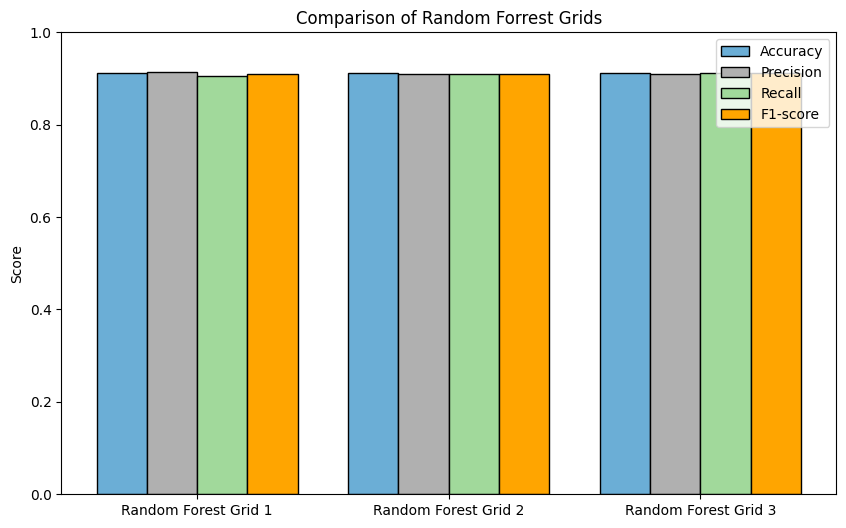

In [22]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_rf))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_rf[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_rf["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Random Forrest Grids")
plt.legend()
plt.show()